In [1]:
! pip install micrograd
# A tiny autograd engine and neural network library in Python, inspired by Andrej Karpathy's micrograd. It provides a simple implementation of automatic differentiation and can be used for educational purposes to understand how backpropagation works in neural networks.

In [2]:
from micrograd.engine import Value
a = Value(-4.0)
b = Value(2.0)
c = a + b
d = a * b + b ** 3
c += c + 1
c += 1 + c + -a
d += d * 2 + (b + a).relu()
d += 3 * d + (b - a).relu()
e = c - d
f = e ** 2
g = f / 2.0
g += 10.0 / f
print(f'{g.data:.4f}') # outcome of the forward pass
g.backward()
print(f'{a.grad:.4f}') # the numercial value of the gradient of g with respect to a
print(f'{b.grad:.4f}') # the numercial value of the gradient of g with respect to b

24.7041
138.8338
645.5773


In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
def f(x):
    return 3*x**2 - 4*x + 5

In [5]:
f(3.0)

20.0

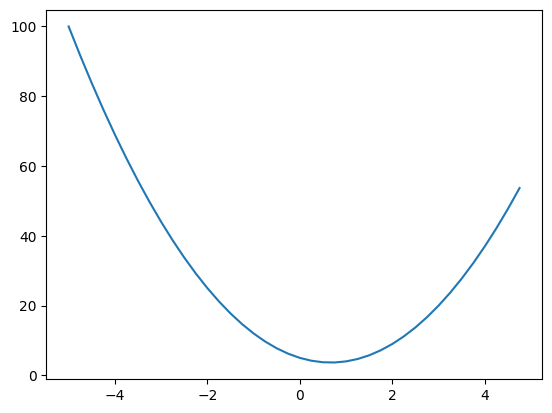

In [6]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [7]:
h = 0.001
x = 3.0
(f(x + h) - f(x)) / h

14.00300000000243

In [8]:
h = 0.000000001
x = 3.0
(f(x + h) - f(x)) / h

14.000001158365194

In [9]:
h = 0.000000001
x = -3.0
(f(x + h) - f(x)) / h

-22.000001820288162

In [10]:
h = 0.0000001
x = 2/3
(f(x + h) - f(x)) / h

2.9753977059954195e-07

In [11]:
# lets get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [12]:
h = 0.0001
# inputs
a = 2.0
b = -3.0
c = 10.0
d1 = a*b + c
a += h
d2 = a*b + c
 
print('d1: ', d1)
print('d2: ', d2)
print('slope: ', (d2 - d1) / h)

d1:  4.0
d2:  3.999699999999999
slope:  -3.000000000010772


In [13]:
class Value:
    def __init__(self, data):
        self.data = data
    
    def __repr__(self):
        return f'Value({self.data})'
    
    def __add__(self, other):
        out = Value(self.data + other.data)
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data)
        return out
    
a = Value(2.0)
b = Value(-3.0)
a + b

Value(-1.0)

In [14]:
a * b

Value(-6.0)

In [15]:
c = Value(10.0)
d= a * b + c
d

Value(4.0)

In [153]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f'Value({self.data})'
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
        
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, power):
        assert isinstance(power, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** power, (self,), f'**{power}')
        
        def _backward():
            self.grad += power * (self.data ** (power - 1)) * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __truediv__(self, other): # self / other
        return self * other**-1
    
    def __radd__(self, other):  
        return self + other
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def __neg__(self): # -self
        return self * -1
    
    def __sub__(self, other): # self - other
        return self + (-other)
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        
        def _backward():
            self.grad = (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def backward(self):
        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [31]:
a = Value(2.0, label= 'a')
b = Value(-3.0, label= 'b')
c = Value(10.0, label= 'c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
d

Value(4.0)

In [32]:
d._prev

{Value(-6.0), Value(10.0)}

In [33]:
d._op

'+'

In [34]:
# brew install graphviz
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangle ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect the this node to it
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

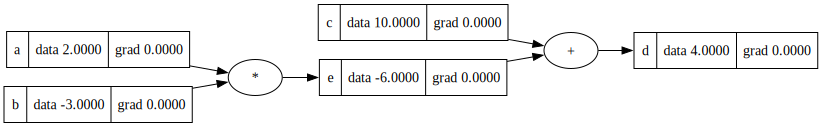

In [35]:
draw_dot(d)

In [36]:
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'

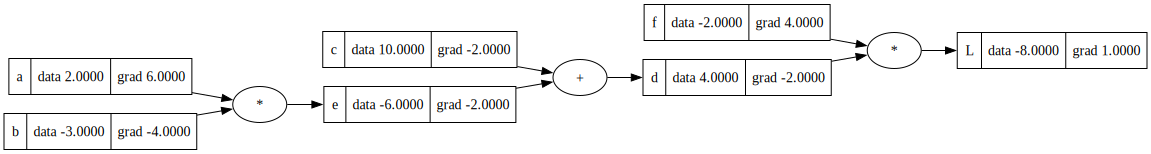

In [52]:
draw_dot(L)

In [51]:
L.grad = 1.0
d.grad = -2
f.grad = 4
a.grad = 6
b.grad = -4
c.grad = -2
e.grad = -2

In [53]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad
e = a * b
d = e + c
L = d * f

print(L.data)

-7.286496


In [48]:
def lol():
    h = 0.001
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d= e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d*f; L.label = 'L'
    L1 = L.data
    
    a = Value(2.0, label='a')
    b = Value(-3.0 + h, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d= e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d*f; L.label = 'L'
    L2 = L.data
    
    print((L2 - L1)/h)

In [49]:
lol()

-3.9999999999995595


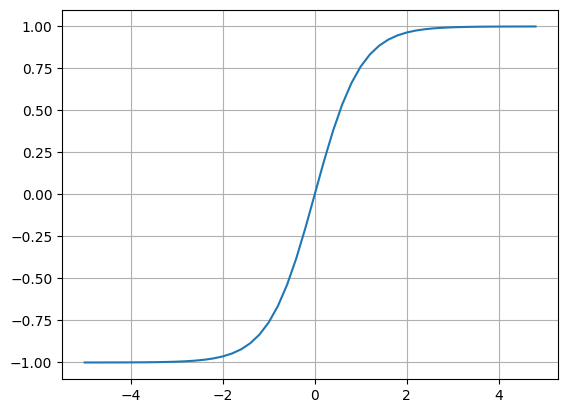

In [54]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2)))
plt.grid()

In [95]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.88137, label= 'b')
# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

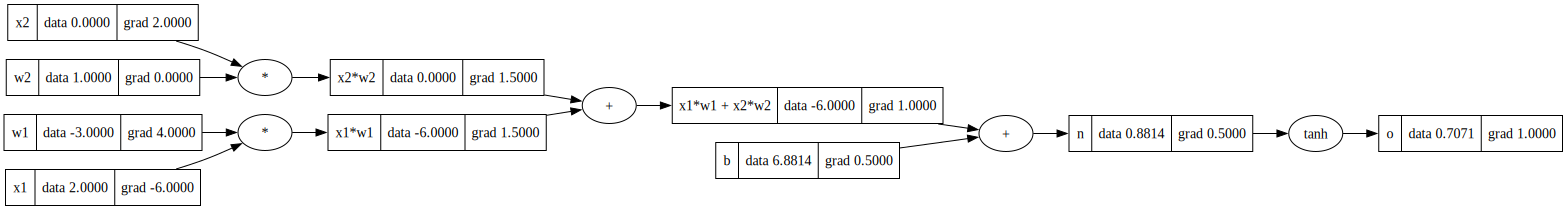

In [88]:
draw_dot(o)
# o = tanh(n)
# do/dn = 1 - o**2

In [87]:
o.grad = 1.0
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)

for node in reversed(topo):
    node._backward()

In [86]:
# 1 - o.data ** 2
n.grad = 0.5
x1w1x2w2.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5
w1.grad = x1.data * x1w1.grad
w2.grad = x2.data * x2w2.grad
x2.grad = w2.data * x2w2.grad
x1.grad = w1.data * x1w1.grad

In [81]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[Value(-3.0),
 Value(2.0),
 Value(-6.0),
 Value(0.0),
 Value(1.0),
 Value(0.0),
 Value(-6.0),
 Value(6.88137),
 Value(0.8813700000000004),
 Value(0.7071049876722272)]

In [76]:
o._backward()

In [77]:
n._backward()

In [78]:
b._backward()

In [79]:
x1w1x2w2._backward()

In [80]:
x1w1._backward()
x2w2._backward()

In [96]:
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()

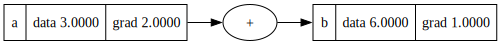

In [97]:
draw_dot(b)

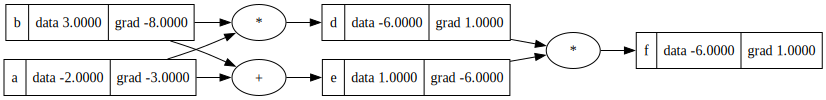

In [98]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'

f.backward()
draw_dot(f)

In [99]:
o.backward()

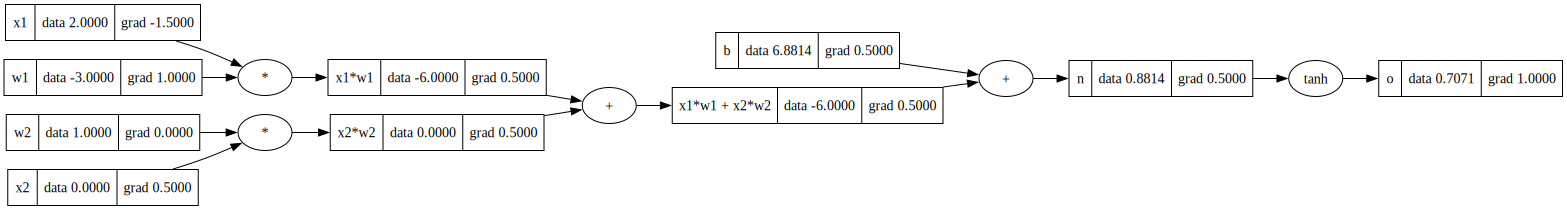

In [100]:
draw_dot(o)

In [101]:
a * 2

AttributeError: 'int' object has no attribute 'data'

In [103]:
2.__mul__(a)

SyntaxError: invalid decimal literal (3803971692.py, line 1)

In [113]:
a = Value(2.0)
b = Value(4.0)
a / b

Value(0.5)

In [114]:
a.exp()

Value(7.38905609893065)

In [122]:
a - b 

Value(-4.88137)

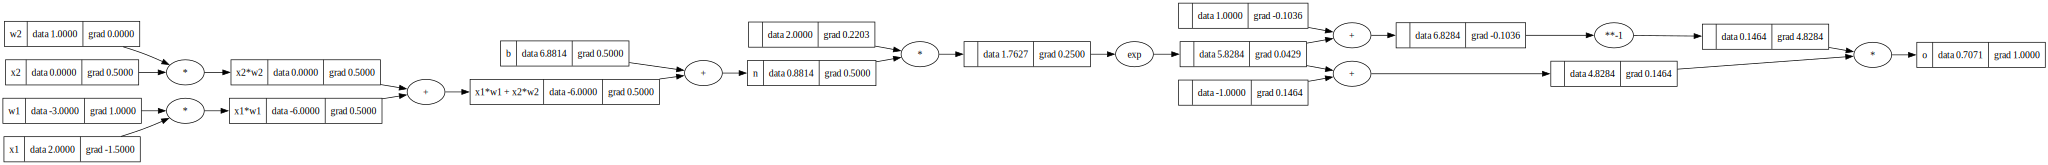

In [121]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.88137, label= 'b')
# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
e = (2*n).exp()
o = (e - 1) / (e + 1); o.label = 'o'
o.backward()
draw_dot(o)

In [124]:
import torch

x1 = torch.tensor(2.0, requires_grad=True)
x2 = torch.tensor(0.0, requires_grad=True)
w1 = torch.tensor(-3.0, requires_grad=True)
w2 = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(6.88137, requires_grad=True)
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)
print(o.data.item())
o.backward()

print('----')
print('x1.grad: ', x1.grad.item())
print('x2.grad: ', x2.grad.item())
print('w1.grad: ', w1.grad.item())
print('w2.grad: ', w2.grad.item())

0.7071050405502319
----
x1.grad:  -1.5000073909759521
x2.grad:  0.5000024437904358
w1.grad:  1.0000048875808716
w2.grad:  0.0


In [125]:
o

tensor(0.7071, grad_fn=<TanhBackward0>)

In [126]:
o.item()

0.7071050405502319

In [128]:
x1.grad

tensor(-1.5000)

In [161]:
import numpy as np
class Neuron:
    def __init__(self, nin):
        self.w = [Value(np.random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(np.random.uniform(-1, 1))
        
    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
        
    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [140]:
x = [2.0, 3.0]
n = Neuron(2)
n(x)

Value(0.7539609137723238)

In [141]:
x = [2.0, 3.0]
n = Layer(2, 3)
n(x)

[Value(-0.9039331838048328),
 Value(0.6304742587123268),
 Value(0.28513113082035646)]

In [162]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(-0.6532084279161255)

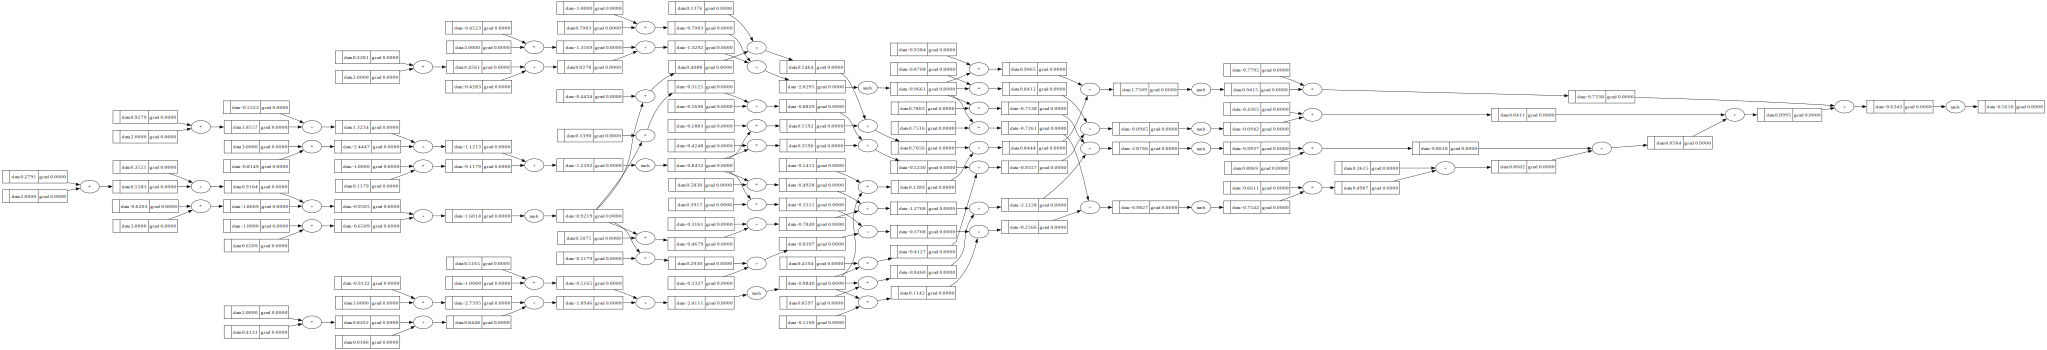

In [143]:
draw_dot(n(x))

In [146]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0]
ypred = [n(x) for x in xs]
ypred

[Value(-0.5610393639773826),
 Value(0.9644494726676123),
 Value(0.28234481736750777),
 Value(-0.5315668912793875)]

In [150]:
[(yout - ygt)**2 for ygt, yout in zip(ys, ypred)]

[Value(2.436843895886911),
 Value(3.85906173066406),
 Value(1.644408230629307),
 Value(2.345697142463207)]

In [155]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(10.286010999643484)

In [156]:
loss.backward()

In [157]:
n.layers[0].neurons[0].w[0].grad

0.4887742988541833

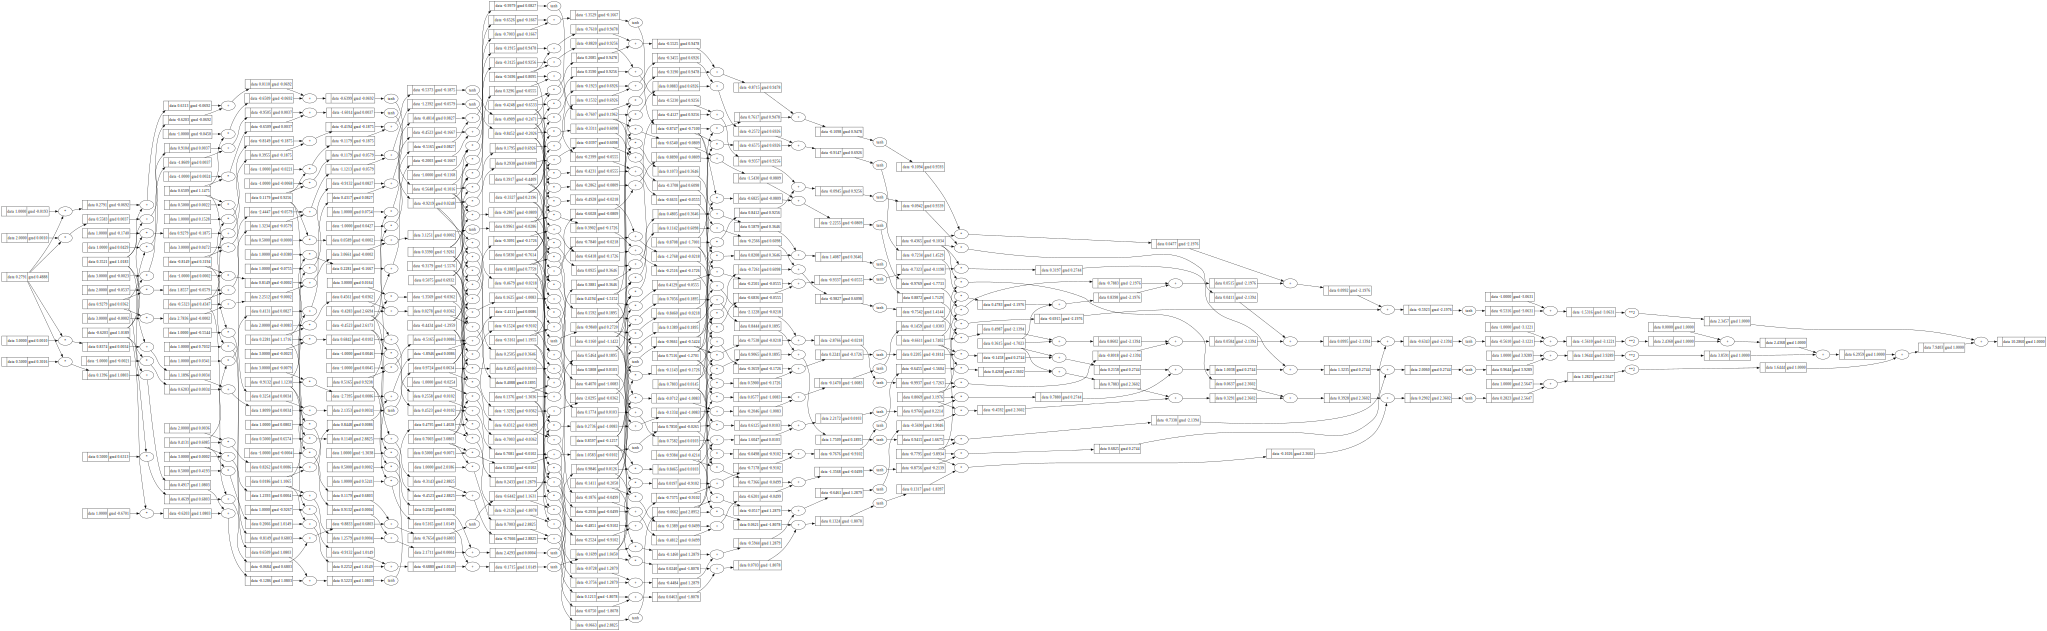

In [158]:
draw_dot(loss)

In [163]:
n.parameters()

[Value(-0.5432517232083294),
 Value(0.770168086270238),
 Value(0.48227184489110364),
 Value(0.19331105773294288),
 Value(-0.3191365176426273),
 Value(-0.7022637526135254),
 Value(-0.4039168500767625),
 Value(0.21592433015539259),
 Value(0.624230457175031),
 Value(0.4225795445396081),
 Value(-0.12921272872166445),
 Value(0.9795639057824121),
 Value(-0.9158904567992647),
 Value(-0.19896890121717892),
 Value(0.947548401845425),
 Value(0.7488145643304633),
 Value(-0.8292428276697399),
 Value(0.13800803072642176),
 Value(0.6204616944029882),
 Value(-0.8493293593917477),
 Value(0.08335027962841424),
 Value(0.4332107974133985),
 Value(0.2785828881520205),
 Value(-0.0847939228120369),
 Value(-0.6307542894874951),
 Value(-0.3126836264388495),
 Value(-0.5301606600964504),
 Value(-0.5593534000695886),
 Value(-0.18381297829775578),
 Value(0.011467095900921098),
 Value(0.27819141544922155),
 Value(-0.2423492696537286),
 Value(-0.3003504907480401),
 Value(-0.3363354442227684),
 Value(0.1680325933058

In [164]:
n.layers[0].neurons[0].w[0].data

-0.5432517232083294

In [165]:
for p in n.parameters():
    p.data += -0.01 * p.grad

In [166]:
ypred

[Value(-0.5610393639773826),
 Value(0.9644494726676123),
 Value(0.28234481736750777),
 Value(-0.5315668912793875)]

In [167]:
for k in range(10):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    # backward pass
    loss.backward()
    
    # update
    for p in n.parameters():
        p.data += -0.01 * p.grad
    
    print(k, loss.data)

0 5.649779876971817
1 4.919487157498537
2 3.5466391701981337
3 3.0574606365130372
4 3.221104243250067
5 3.0327449639505204
6 2.4906019077437365
7 1.8179145695651118
8 1.4430562981916744
9 1.6550340626666138


In [168]:
for k in range(20):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    # backward pass
    loss.backward()
    
    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad
    
    print(k, loss.data)

0 1.658507821171665
1 0.1427600975143948
2 0.20298994728208952
3 0.319375912328054
4 0.03548093387832409
5 0.02374872769041418
6 0.015015902216329466
7 0.009272501986862466
8 0.005699470990486396
9 0.0035162325844294864
10 0.0021834896730344618
11 0.001365108508929472
12 0.0008585862762527372
13 0.0005426566494187822
14 0.00034428863377834653
15 0.00021906456881705746
16 0.0001396839379979058
17 8.920553874620693e-05
18 5.70317307625065e-05
19 3.649042773139436e-05


In [169]:
for k in range(10):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()
    
    # update
    for p in n.parameters():
        p.data += -0.01 * p.grad
    
    print(k, loss.data)

0 2.336016792060267e-05
1 2.3359732883439887e-05
2 2.335929786246654e-05
3 2.3358862857682286e-05
4 2.335842786908527e-05
5 2.3357992896674398e-05
6 2.3357557940450087e-05
7 2.335712300040972e-05
8 2.335668807655296e-05
9 2.335625316888023e-05
